# Intro to plotting Nextstrain trees with Baltic 

Baltic is a super useful plotting software that allows you to interact with and plot phylogenies. Baltic is downloadable from here: https://github.com/evogytis/baltic. This git repo also contains some nice documentation about baltic, its various classes, and how to use it. In the following notebook, I have baltic installed locally in my src folder, which I reference. The below includes some very basic information about how to use baltic to access trees and the information within them. 

In [61]:
bt = imp.load_source('baltic', '/Users/lhmoncla/src/baltic/baltic/baltic.py')

import numpy as np
import json
import pandas as pd

In [45]:
# define your tree path here. Baltic can read in jsons or newicks. Here we will do json, because it's harder

tree_path = "../auspice/flu_group_1_ha.json"
#tree_path = "../../../avian-flu/auspice/avian-flu_h5n1_ha_2y.json"

In [46]:
"""this is a function to load a tree json produced by Nextstrain into a baltic object. In the current json 
versions, the top level JSON is divided into two parts: metadata and tree. This simple script breaks the json
into the two sections, and assigns tree to the tree portion. The json translation section of this tells baltic 
how to intepret particular attributes. Here, we assign absolute time to 'div'."""

def load_tree_json(tree_path):
    
    with open(tree_path, "r") as json_file:
        tree_json = json.load(json_file)
    tree_object=tree_json['tree']
    meta=tree_json['meta']
    json_translation={'absoluteTime':lambda k: k.traits['node_attrs']['div'],'name':'name'} ## allows baltic to find correct attributes in JSON, height and name are required at a minimum

    tree=bt.loadJSON(tree_object,json_translation)
    
    return(tree)

In [ ]:
"""alternatively, you can load a newick tree"""

def load_tree_newick(tree_path):
    tree = bt.loadNewick(tree_path)
    return(tree)

In [47]:
"""load in the json, and store as a baltic object called tree"""

tree = load_tree_json(tree_path)


Tree height: 0.748098
Tree length: 27.499593
annotations present

Numbers of objects in tree: 4363 (2085 nodes and 2278 leaves)



In [48]:
"""Parse out some basic information 

Baltic will organize trees as essentially large dictionaries that can be parsed through. To iterate through a
tree, iterate through every object in the tree and print out its attributes. Each baltic object will either be 
a node or a leaf. All nodes and leaves will have attributes, which are accessible with the .attributes notation. 
all nodes and leaves will also have a name.

This short script sets a counter so that we don't overwhelm the memory of jupyter notebook by printing too much 
at once. This will simply print the first 10 tree nodes/leaves. 
"""


counter = 0

for k in tree.Objects: 
    counter +=1 
    if counter < 10: 
        
        """printing k will print a string version of the object itself"""
        print(k)
        
        """.name will print the objects name"""
        print(k.name)     

NODE_0000038
NODE_0000518
NODE_0000224
NODE_0000031
NODE_0000029
NODE_0000030
A/duck/Malaysia/91/1997
A/duck/Malaysia/20/1998
NODE_0000028


In [53]:
"""
Testing out if a branch is a node or leaf, and pulling information from it. 

All nodes and leaves have attributes, and nodes and leaves will contain different attributes. The easiest way to 
figure out what attributes something has is to test it by printing it out. All attributes are essentially stored 
in these large dictionaries. You can access any of these attributes by using dictionary access syntax and 
storing as variables. 
"""

counter = 0

for k in tree.Objects: 
    counter +=1 

   #if the branch is a node, print its type and its traits
    if k.branchType == "node" and counter < 10:
        print(k.branchType)
        print(k.traits)
        
    # if the branch is a leaf, print its type and its traits
    elif k.branchType == "leaf" and counter < 10: 
        print(k.branchType)
        print(k.traits)

node
{'name': 'NODE_0000038', 'node_attrs': {'div': 0, 'num_date': {'value': 1623.4250345835176, 'confidence': [1617.9892129892273, 1634.5653555568442]}}, 'branch_attrs': {}, 'num_date': 1623.4250345835176, 'num_date_confidence': [1617.9892129892273, 1634.5653555568442]}
node
{'name': 'NODE_0000518', 'node_attrs': {'div': 0.022408367976937526, 'num_date': {'value': 1638.0939611838808, 'confidence': [1633.7049341190032, 1649.920516454151]}}, 'branch_attrs': {}, 'num_date': 1638.0939611838808, 'num_date_confidence': [1633.7049341190032, 1649.920516454151]}
node
{'name': 'NODE_0000224', 'node_attrs': {'div': 0.12431167797693753, 'num_date': {'value': 1709.6557550061675, 'confidence': [1702.5002420267367, 1721.9907122050186]}}, 'branch_attrs': {}, 'num_date': 1709.6557550061675, 'num_date_confidence': [1702.5002420267367, 1721.9907122050186]}
node
{'name': 'NODE_0000031', 'node_attrs': {'div': 0.4083165079769375, 'num_date': {'value': 1930.150926208595, 'confidence': [1926.2159912782224, 1

# Plotting with baltic and matplotlib

Below is a somewhat complicated example of plotting a baltic tree. This will use the above tree jsons to plot out 2 trees, with associated text labels. This code is all using matplotlib to plot out baltic trees, so most of the syntax is getting matplotlib to plot. 

In [54]:
"""This function just generates a metadata dictionary from the metadata file. This can sometimes be pretty 
useful for plotting information that may not be stored in your tree"""

def generate_metadata_dictionary(metadata_path):
    metadata = {}

    with open(metadata_path, "r") as infile: 
        for line in infile: 
            if "isolate_id" not in line:
                strain = line.split("\t")[0].replace("?","_")  #iqtree will do this replacement
                ha_type = line.split("\t")[-1].strip()
                date = line.split("\t")[3]
                if date == "?":
                    date1 = "XXXX-XX-XX"
                else:
                    date1 = date

                metadata[strain] = {"ha_type":ha_type, "date":date1}
    return(metadata)

In [63]:
"""This massive function takes several inputs and produces a large tree. It is written to be modular, such that
you can pass it a different tree and have it work, but parts of it are a bit hard coded (eg., the divergence 
values."""


def plot_full_genome_divergence_tree(tree,metadata,colors,vaccines, ha_order, vax_distances, output_name, width, height):
    fig,ax = plt.subplots(figsize=(width, height),facecolor='w')

    divergence = [0,0.2,0.4,0.6,0.8]
    #[ax.axvline(i,ls='--',lw=2,color='grey',zorder=0, alpha=0.6) for i in divergence]

    # # this sets the vertical dashed lines on the tree; plot a dashed line every other year from 1990 to 2020
    branchWidth=1.25 ## default branch width
    tipSize = 40
    labelSize = 12
    print(tree.ySpan)

    # k objects are tips, nodes, branches
    for k in tree.Objects: ## iterate over objects in tree
        y=k.y ## or use absolute time instead
        x=k.absoluteTime
        
        
        if x==None: ## matplotlib won't plot Nones, like root
            x=0.0
        if 'node_attrs' in k.parent.traits:
            xp=k.parent.absoluteTime ## get x position of current object's parent
        else:
            xp = x
        
        
        # if we are at a leaf, plot this way -> below we3 assign size, colors, z order, and labels 
        if isinstance(k,bt.leaf) or k.branchType=='leaf': ## if leaf...
            #x=decimalDate(k.name.split('_')[-1],variable=True) ## get x position from name
            
            strain = k.numName
            ha_type = metadata[strain]['ha_type']
            c=colors[ha_type]
            
            s=tipSize 
            m = "."
            z=11
            label_text = ""
            c=colors[ha_type]
            label_position = k.absoluteTime, k.y
            
            ax.scatter(x,y,s=s,facecolor=c,edgecolor='none',marker=m,zorder=z) ## plot circle for every tip
            ax.scatter(x,y,s=s+0.8*s,facecolor='k',edgecolor='none',marker=m,zorder=10) ## plot black circle underneath
        
        # if we are at a node, plot this way -> below we assign colors and line thickness 
        elif isinstance(k,bt.node) or k.branchType=='node': ## if node...
            c="#696969"
            ax.plot([x,x],[k.children[-1].y,k.children[0].y],lw=branchWidth,color=c,ls='-',zorder=9) #color=node_colors[node_types[k]["node_community_status"]]

        ax.plot([xp,x],[y,y],lw=branchWidth,color=c,ls='-',zorder=9)

        # add in a legend
        han_list = []


    """now, go back and plot the x's"""
    for k in tree.Objects: ## iterate over objects in tree
        y=k.y ## or use absolute time instead
        x=k.absoluteTime
        
        
        if x==None: ## matplotlib won't plot Nones, like root
            x=0.0
        if 'node_attrs' in k.parent.traits:
            xp=k.parent.absoluteTime ## get x position of current object's parent
        else:
            xp = x

        if isinstance(k,bt.leaf) or k.branchType=='leaf': ## if leaf...
            strain = k.numName
            ha_type = metadata[strain]['ha_type']
            
            if strain in vaccines:
                s = tipSize*4
                m = "X"
                c="black"
                z=12
                label_text = k.numName.title() + " (" + ha_type.upper() + ")"
                label_position = k.absoluteTime + vax_distances[strain]["x"], k.y + vax_distances[strain]["y"]
            
                # plot tthe X's with labels
                ax.scatter(x,y,s=s,facecolor=c,edgecolor='none',marker=m,zorder=z) ## plot circle for every tip
                ax.scatter(x,y,s=s+0.8*s,facecolor='k',edgecolor='white',linewidth=1.5,marker=m,zorder=z) ## plot black circle underneath
                ax.text(x,y,position=label_position,s=label_text,size=labelSize,zorder=13)
            else:
                pass
        else:
            pass
    
    
    # bbox to anchor puts a bounding box around where you want the legend to go, prop part is for text size
    #ax.legend(handles = han_list, markerfirst = True, frameon=False, bbox_to_anchor=[0.8, 1], loc=2, prop={'size': 24})
    for ha_type in ha_order:
        marker = mlines.Line2D(range(1), range(1), color = colors[ha_type], marker='o', markerfacecolor = colors[ha_type], label = ha_type.replace("_"," ").upper(), markersize = 6)
        han_list.append(marker)

    # set axis limits, remove border lines         
    ax.spines['left'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)
    #ax.spines['bottom'].set_visible(False)

    #ax.set_xlim(0,0.0125)
    ax.set_ylim(-15,tree.ySpan+20)
    ax.tick_params(axis='y',labelsize=0,size=0)
    ax.tick_params(axis='x',labelsize=16,size=5, width=2,color='grey')
    ax.set_yticklabels([])
    ax.set_xticks(divergence)
    plt.xlabel("Divergence", fontsize=16)

    # in order to get the legend to plot without being transparent, over the plot, it needs to be here with frame set to true
    # bbox arguments are: x, y, with 0 being furthest left and bottom
    ax.legend(handles = han_list, markerfirst = True, edgecolor="white", framealpha=1, bbox_to_anchor=[-0.15, 0.0], loc=3,prop={'size': 14}, facecolor='w')

    plt.tight_layout()
    plt.gcf().subplots_adjust(right=0.88)
    plt.savefig(output_name, bbox_inches="tight")

    plt.show()

# Run 

In Figtree, I manually rooted the tree (midpoint) and ordered the nodes to be in descending order. Then, export as newick and check "export as displayed" or something like that. 

In [65]:
# try instead, clustering into regions and plotting it that way; we could do: west, 2 midwests, 2 souths, northeast
group_2_ha = ["h3","h4","h7","h10","h14","h15"]
group_1_ha = ["h1","h2","h5","h6","h8","h9","h11","h12","h13","h16","h17","h18"]
all_ha_order = ["h1","h2","h3","h4","h5","h6","h7","h8","h9","h10","h11","h12","h13","h14","h15","h16","h17","h18"]


colors_group2 = {"h3":"#438B62",
          "h4":"#EEA160",
          "h7":"#F9E7C3",
          "h10":"#2664A5",
          "h14":"#695B82", #"#2664A5",
          "h15":"#B2313D",    
         "":"#000000"}


colors_group1 = {"h1":"#B0DBC2",
          "h2":"#93B2D2",
          "h5":"#5CA7A4",
          "h6":"#695B82",
          "h8":"#C5656E", #"#2664A5",
          "h9":"#438B62",    
          "h11":"#B2313D", 
          "h12":"#EEA160",
          "h13":"#2664A5",
          "h16":"#F9E7C3", #"#CF7E86",
          "h17":"#2D1E45",
          "h18":"#EEC060",
         "":"#000000"}


colors = {"h1":"#B2313D",
          "h2":"#695B82",
        "h3":"#2664A5",
          "h4":"#93B2D2",
          "h5":"#C5656E",
          "h6":"#F9E7C3",
          "h7":"#5CA7A4",
          "h8":"#B3C8BC",
          "h9": "#742028",
          "h10":"#544370",
          "h11":"#EEA160",
          "h12":"#EEA160",
          "h13":"#EEA160",
          "h14":"#EEA160",
          "h15":"#CF7E86",
          "h16":"#EEA160",
          "h17":"#EEA160",
          "h18":"#EEA160",
          "":"#000000"}


uncertainty_color = "#B9B9B9"

vaccines = ["A/Michigan/45/2015","a/japan/305/1957","A/Singapore/INFIMH-16-0019/2016","a/duck/czech/1956",
       "A/Vietnam/1203/2004","a/taiwan/2/2013","A/Shanghai/2/2013","a/mallard/sweden/24/2002",
       "A/HongKong/33982/2009","a/jiangxi/09037/2014","A/shoveler/netherlands/18/1999",
       "a/mallard/interior_alaska/7mp0167/2007","a/shorebird/delaware/68/2004","a/mallard/gurjev/263/1982",
       "a/shearwater/west_australia/2576/1979","a/black-headed_gull/sweden/5/99",
       "a/little_yellow-shouldered_bat/guatemala/060/2010","a/flat_faced_bat/peru/033/2010",
           "B/Colorado/6/2017", "B/Phuket/3073/2013"]

vax_distances = {"A/Shanghai/2/2013":{"x":0.05,"y":-14},"a/shearwater/west_australia/2576/1979": {"x":0.04,"y":0}, 
                  "a/jiangxi/09037/2014":{"x":0.04,"y":-2},"A/Singapore/INFIMH-16-0019/2016":{"x":0.02,"y":-2},
                 "a/mallard/gurjev/263/1982":{"x":0.06,"y":0},"a/duck/czech/1956":{"x":0.08,"y":-2},
                
                "A/shoveler/netherlands/18/1999":{"x":0.07,"y":-11}, "a/black-headed_gull/sweden/5/99":{"x":0.05,"y":0},
                "a/shorebird/delaware/68/2004":{"x":0.12, "y":-7}, "A/HongKong/33982/2009":{"x":0.1,"y":-5},
                "a/mallard/sweden/24/2002":{"x":0.06,"y":-6},"a/mallard/interior_alaska/7mp0167/2007":{"x":0.05,"y":-9},
                "a/little_yellow-shouldered_bat/guatemala/060/2010":{"x":0.03,"y":-75},
                 "a/flat_faced_bat/peru/033/2010":{"x":0.045,"y":-35},
                "a/taiwan/2/2013":{"x":0.03,"y":-12}, "A/Michigan/45/2015":{"x":0.03,"y":-5},
                "A/Vietnam/1203/2004":{"x":0.07,"y":8}, "a/japan/305/1957":{"x":0.07,"y":-30}}

In [66]:
"""
I sometimes like to hard code in this little function, which adds the current date to my plot name. That 
way, if I go back in the future and redo the plot, it won't automatically plot over the old one. It also serves 
as a nice way of keeping track of different versions.
""" 

from datetime import date
today = date.today()
current_date = str(today.strftime("%Y-%m-%d"))


Tree height: 0.542604
Tree length: 10.301235
annotations present

Numbers of objects in tree: 1868 (874 nodes and 994 leaves)

994


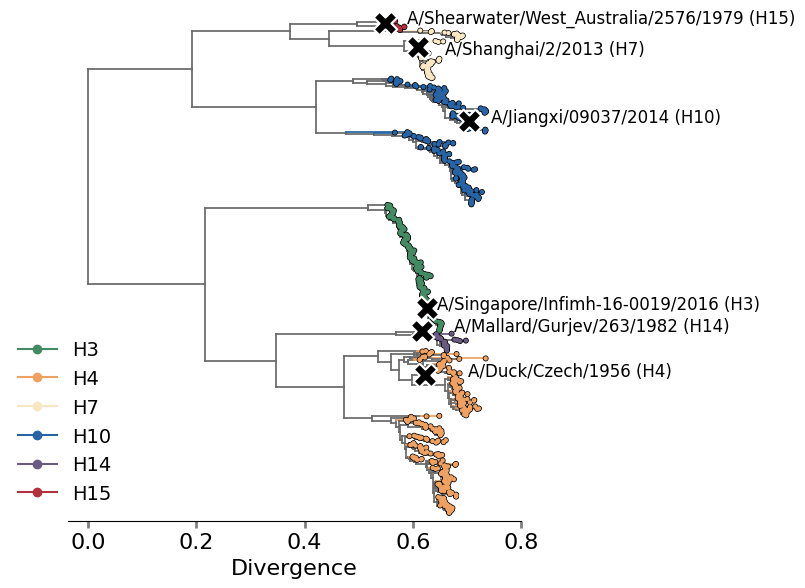

In [67]:
# plot the group 2 HA trees

# group 2 ha
tree_path_newick = "../results/tree-raw_group_2_ha.nwk"
tree_path_json = "../auspice/flu_group_2_ha.json"
metadata_path = "../results/metadata_group_2_ha.tsv"
ha_order = group_2_ha
colors = colors_group2
output_name = "group-2-ha-divergence-tree-"+current_date+".pdf"
width = 6
height = 6

tree = load_tree_json(tree_path_json)
tree.traverse_tree() ## required to set heights

metadata = generate_metadata_dictionary(metadata_path)
plot_full_genome_divergence_tree(tree,metadata,colors,vaccines,ha_order,vax_distances,output_name, width, height)


Tree height: 0.748098
Tree length: 27.499593
annotations present

Numbers of objects in tree: 4363 (2085 nodes and 2278 leaves)

2278


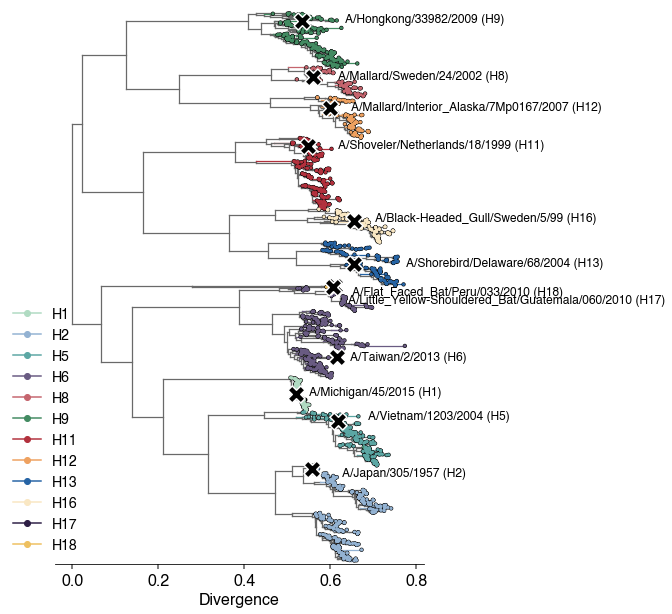

In [43]:
# group 1 ha
tree_path_newick = "../results/tree-raw_group_1_ha.nwk"
tree_path_json = "../auspice/flu_group_1_ha.json"
metadata_path = "../results/metadata_group_1_ha.tsv"
ha_order = group_1_ha
colors = colors_group1
output_name = "group-1-ha-divergence-tree-"+current_date+".pdf"
width = 7
height = 9

tree = load_tree_json(tree_path_json)
tree.traverse_tree() ## required to set heights

metadata = generate_metadata_dictionary(metadata_path)
metadata['a/japan/305_/1957'] = {"ha_type": "h2", "date":"1957-01-01"}

plot_full_genome_divergence_tree(tree,metadata,colors,vaccines,ha_order,vax_distances,output_name, width, height)